# Exploratory Data Analysis (EDA)

## Objectives

- Load the stock dataset
- Explore the dataset structure
- Check for missing values
- Generate descriptive statistics
- Visualize stock prices
- Analyze daily returns

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [10]:
stock = pd.read_csv(
    "../data/raw/reliance.csv",
    parse_dates=["Date"]
)

stock.set_index("Date", inplace=True)

stock.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,189.125381,202.959000,203.896194,201.987518,202.593277,2963643
2015-01-02,188.624832,202.421829,204.821960,202.136108,203.004715,7331366
2015-01-05,186.558685,200.204575,203.644760,199.804550,202.296112,10103941
2015-01-06,178.091797,191.118393,199.553116,190.181198,198.867371,18627980
2015-01-07,181.968475,195.278610,196.307236,191.324127,191.346985,20720312


In [11]:
stock = pd.read_csv(
    "../data/raw/reliance.csv",
    parse_dates=["Date"]
)

stock.set_index("Date", inplace=True)

stock.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,189.125381,202.959000,203.896194,201.987518,202.593277,2963643
2015-01-02,188.624832,202.421829,204.821960,202.136108,203.004715,7331366
2015-01-05,186.558685,200.204575,203.644760,199.804550,202.296112,10103941
2015-01-06,178.091797,191.118393,199.553116,190.181198,198.867371,18627980
2015-01-07,181.968475,195.278610,196.307236,191.324127,191.346985,20720312


In [12]:
stock.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2466 entries, 2015-01-01 to 2024-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2466 non-null   float64
 1   Close      2466 non-null   float64
 2   High       2466 non-null   float64
 3   Low        2466 non-null   float64
 4   Open       2466 non-null   float64
 5   Volume     2466 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 134.9 KB


In [13]:
print("Dataset Shape:", stock.shape)

Dataset Shape: (2466, 6)


In [14]:
stock.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [15]:
stock.describe()

,Adj Close,Close,High,Low,Open,Volume
count,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2.466000e+03
mean,727.140955,743.464490,751.604263,735.975204,744.002411,1.843374e+07
std,417.892002,419.908974,423.817694,416.329666,420.216435,1.355283e+07
min,172.692154,185.323807,186.912460,182.055069,186.661026,1.705656e+06
25%,313.979446,329.048340,331.257019,326.513931,329.322639,1.071503e+07
50%,639.019440,656.056580,666.342804,650.444855,659.188171,1.464605e+07
75%,1115.900452,1134.297363,1146.336761,1124.098236,1135.526123,2.109906e+07
max,1581.824463,1600.900024,1608.800049,1585.500000,1604.449951,1.426834e+08


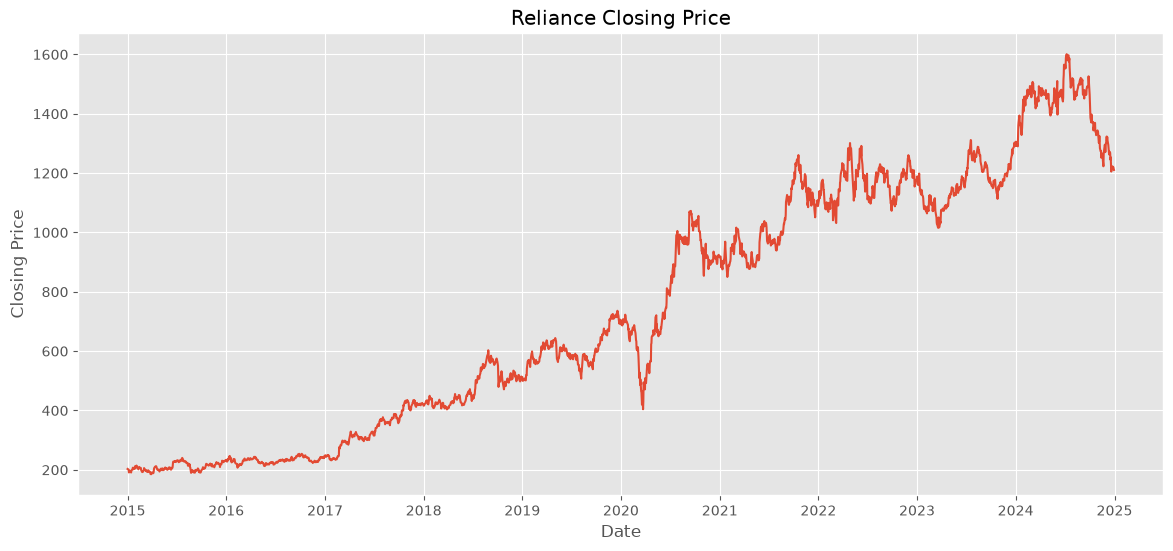

In [16]:
plt.figure(figsize=(14,6))

plt.plot(stock.index, stock["Close"])

plt.title("Reliance Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

In [17]:
stock["Daily_Return"] = stock["Close"].pct_change()

stock.head()

,Adj Close,Close,High,Low,Open,Volume,Daily_Return
Date,,,,,,,
2015-01-01,189.125381,202.959000,203.896194,201.987518,202.593277,2963643,NaN
2015-01-02,188.624832,202.421829,204.821960,202.136108,203.004715,7331366,-0.002647
2015-01-05,186.558685,200.204575,203.644760,199.804550,202.296112,10103941,-0.010954
2015-01-06,178.091797,191.118393,199.553116,190.181198,198.867371,18627980,-0.045384
2015-01-07,181.968475,195.278610,196.307236,191.324127,191.346985,20720312,0.021768


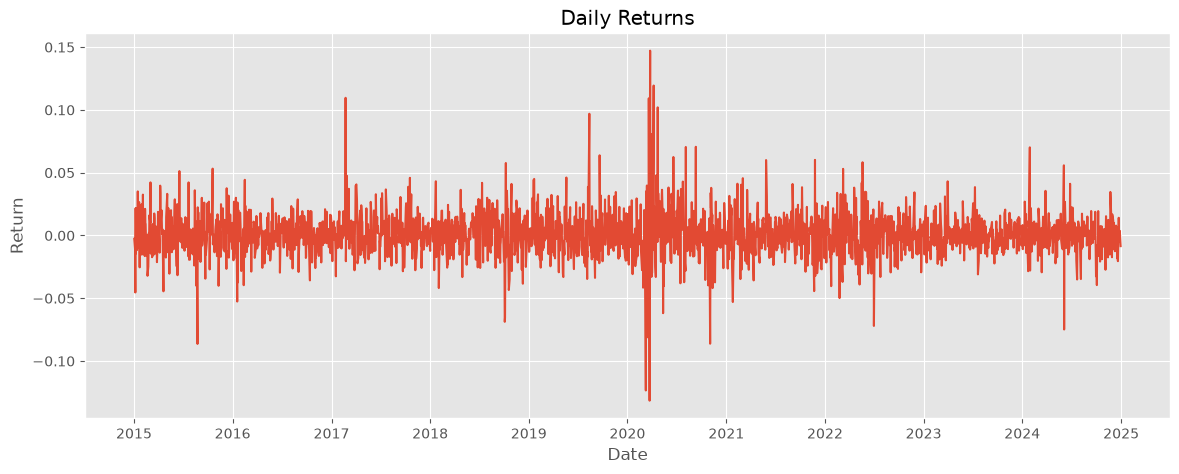

In [18]:
plt.figure(figsize=(14,5))

plt.plot(stock.index, stock["Daily_Return"])

plt.title("Daily Returns")

plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

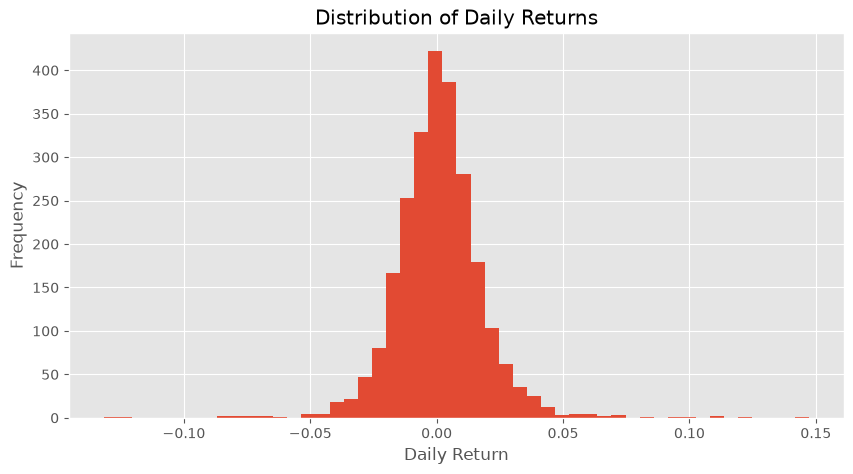

In [19]:
plt.figure(figsize=(10,5))

plt.hist(stock["Daily_Return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [20]:
stock.corr(numeric_only=True)

,Adj Close,Close,High,Low,Open,Volume,Daily_Return
Adj Close,1.000000,0.999977,0.999799,0.999819,0.999556,-0.071705,-0.005293
Close,0.999977,1.000000,0.999835,0.999821,0.999572,-0.070287,-0.004896
High,0.999799,0.999835,1.000000,0.999737,0.999800,-0.064096,-0.015239
Low,0.999819,0.999821,0.999737,1.000000,0.999783,-0.077627,-0.016051
Open,0.999556,0.999572,0.999800,0.999783,1.000000,-0.071640,-0.027551
Volume,-0.071705,-0.070287,-0.064096,-0.077627,-0.071640,1.000000,0.134873
Daily_Return,-0.005293,-0.004896,-0.015239,-0.016051,-0.027551,0.134873,1.000000


## Conclusion

### Key Observations

- The dataset contains historical daily stock prices for Reliance Industries.
- No significant missing values were found.
- The stock price shows an overall upward trend over the selected period.
- Daily returns fluctuate around zero, with occasional large market movements.
- The dataset is clean and ready for feature engineering in the next notebook.